   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

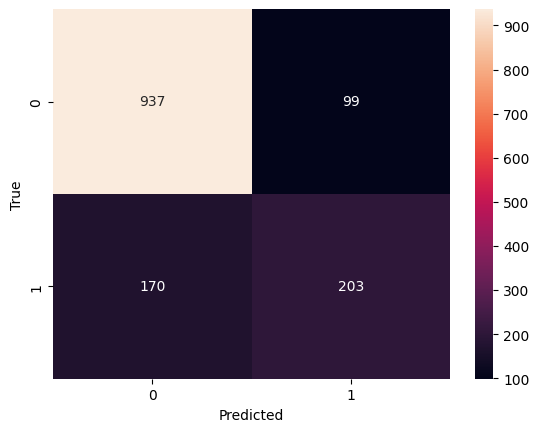

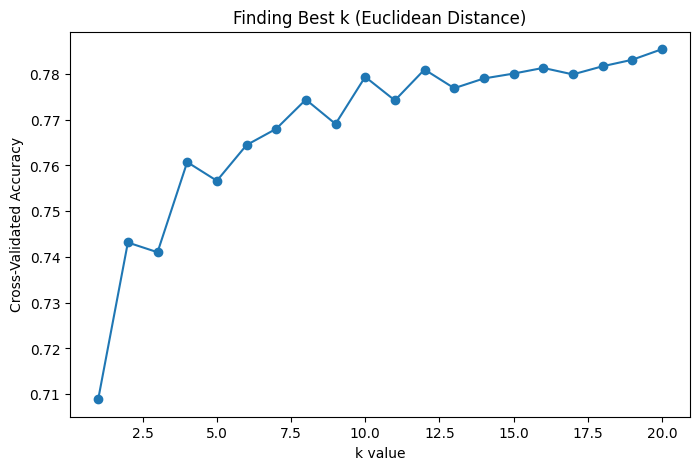


=== Manhattan Distance ===
Best k value: 20
Accuracy: 0.8026969481902059


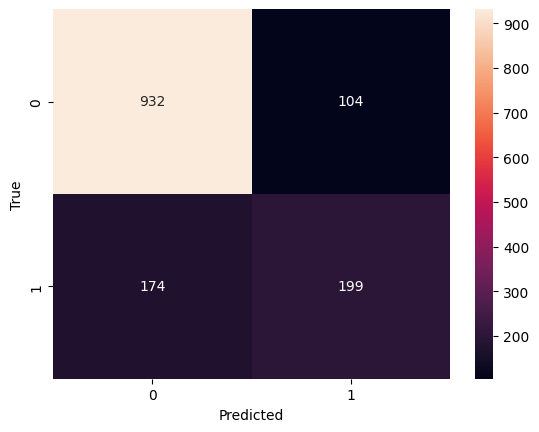

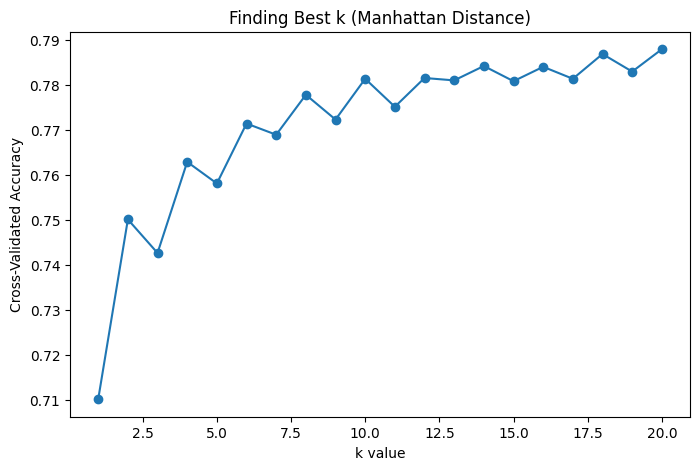


=== Minkowski(p=3) Distance ===
Best k value: 18
Accuracy: 0.8041163946061036


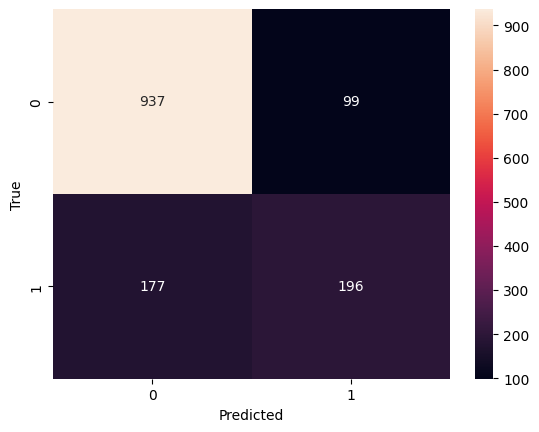

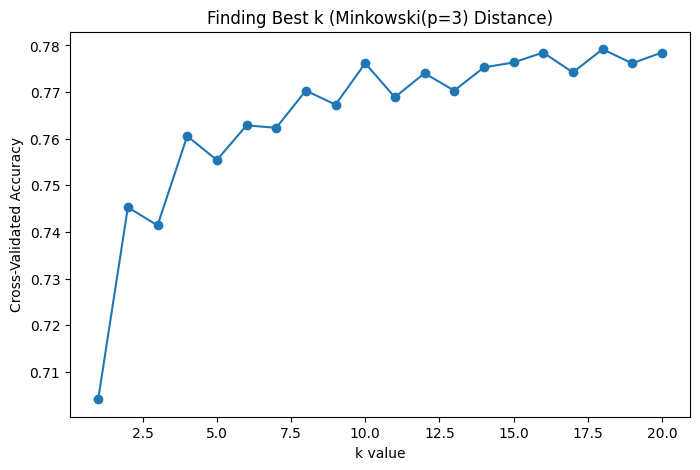

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
import seaborn as sns
import pandas as pd

url="https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df=pd.read_csv(url)
print(df.head())
print(df.info())

# --- Preprocessing Steps ---
# 1. Convert 'TotalCharges' to numeric, coercing errors and filling NaNs
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 2. Convert 'Churn' target variable to numeric (0 and 1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Drop 'customerID' column as it's an identifier and not a feature
df = df.drop(columns=['customerID'])

# Separate features (x) and target (y)
x=df.drop(columns=['Churn'],axis=1)
y=df['Churn']

# 4. Identify categorical columns and apply one-hot encoding
categorical_cols = x.select_dtypes(include='object').columns
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True) # drop_first to avoid multicollinearity

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

metrics={
    'Euclidean':('minkowski',2),
    'Manhattan':('minkowski',1),
    'Minkowski(p=3)':('minkowski',3)
}
for name,(metric,p) in metrics.items():
  print(f"\n=== {name} Distance ===")
  k_values=range(1,21)
  cv_scores=[]
  for k in k_values:
    knn=KNeighborsClassifier(n_neighbors=k,metric=metric,p=p)
    scores=cross_val_score(knn,x_train,y_train,cv=5,scoring='accuracy')
    cv_scores.append(scores.mean())

  best_k=k_values[np.argmax(cv_scores)]
  print(f"Best k value: {best_k}")
  knn=KNeighborsClassifier(n_neighbors=best_k,metric=metric,p=p)
  knn.fit(x_train,y_train)
  y_pred=knn.predict(x_test)
  accuracy=accuracy_score(y_test,y_pred)
  print(f"Accuracy: {accuracy}")
  cm=confusion_matrix(y_test,y_pred)
  sns.heatmap(cm,annot=True,fmt='d')
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.show()
  plt.figure(figsize=(8,5))
  plt.plot(k_values,cv_scores,marker='o')
  plt.xlabel('k value')
  plt.ylabel('Cross-Validated Accuracy')
  plt.title(f"Finding Best k ({name} Distance)")
  plt.show()